# MWE: a smooth closure-phase likelihood

Every likelihood in virgil (grids, limits, samplers and, soon, image fits) now goes through one function, `virgil.likelihood.whitened_residuals`. For visibilities and projected (kernel or DISCO) phases it returns (model − data)/σ as before. For closure phases, which wrap at ±π, it returns the *chord* 2 sin(Δ/2)/σ instead of the wrapped difference Δ/σ. The square of the chord, 2(1 − cos Δ)/σ², is the exponent of a von Mises distribution with concentration 1/σ². It agrees with Δ²/σ² for small residuals, but it is smooth where Δ wraps.

This notebook shows the old and new phase terms, what they do to a χ² surface and its gradient, and one side benefit in float32. You should come away knowing why fits and samplers behave better with the new term, and that well-fitting models are unaffected.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as onp

from virgil.likelihood import whitened_residuals
from virgil.models import BinaryModelCartesian
from virgil.oidata import OIData

template = OIData(str(root / "data" / "NuHor_F480M.oifits"))
truth = BinaryModelCartesian(120.0, 80.0, 0.8)  # bright, so phases reach ±π
data = template.with_model(truth, key=jax.random.PRNGKey(0))
n_vis, sigma = data.vis.size, data.d_phi
print(
    f"{data.phi.size} closure phases on real ν Hor AMI coverage (simulated values)"
)

35 closure phases on real ν Hor AMI coverage (simulated values)


## The two phase terms

For a single closure phase, the old term is the square of the residual wrapped into [−π, π), and the new one is the squared chord. Both are shown in units of σ², so they depend only on the residual Δ. The old curve has a cusp at ±π, where its slope jumps from +2π to −2π; the new one turns over smoothly and peaks at 4.

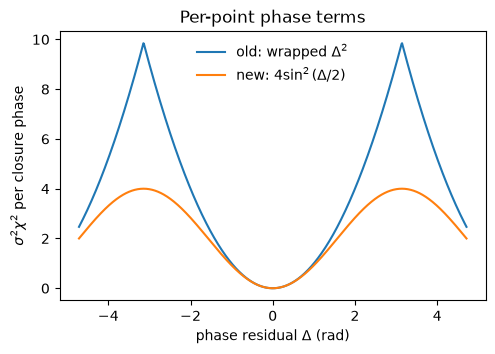

In [2]:
delta = jnp.linspace(-1.5 * jnp.pi, 1.5 * jnp.pi, 801)
wrapped = jnp.mod(delta + jnp.pi, 2 * jnp.pi) - jnp.pi

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(delta, wrapped**2, label=r"old: wrapped $\Delta^2$")
ax.plot(delta, 4 * jnp.sin(delta / 2) ** 2, label=r"new: $4\sin^2(\Delta/2)$")
ax.set(
    xlabel=r"phase residual $\Delta$ (rad)",
    ylabel=r"$\sigma^2 \chi^2$ per closure phase",
    title="Per-point phase terms",
)
ax.legend(frameon=False)
plt.show()

## A χ² slice through a phase-wrap region

Moving a trial companion away from the truth drives some model closure phases across ±π relative to the data. Along a slice in right ascension, the old χ² picks up a kink every time one residual crosses the wrap. With the new term the surface is smooth, which is what gradient-based optimisers and Hamiltonian samplers need. The old χ² is computed here from `OIData.residuals`, which still wraps phases for display.

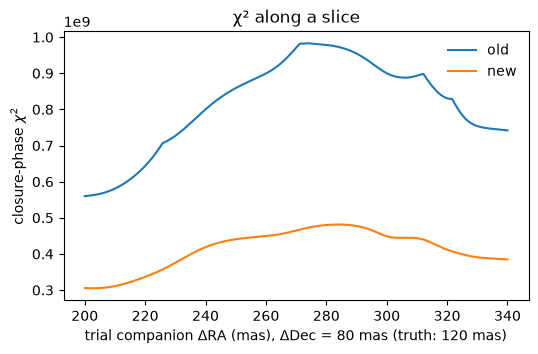

In [3]:
def chi2_old(dra):
    model = BinaryModelCartesian(dra, 80.0, 0.8)
    return jnp.sum((data.residuals(data.model(model))[n_vis:] / sigma) ** 2)


def chi2_new(dra):
    model = BinaryModelCartesian(dra, 80.0, 0.8)
    return jnp.sum(whitened_residuals(model, data)[n_vis:] ** 2)


dra = jnp.linspace(200.0, 340.0, 1401)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(dra, jax.vmap(chi2_old)(dra), label="old")
ax.plot(dra, jax.vmap(chi2_new)(dra), label="new")
ax.set(
    xlabel=r"trial companion $\Delta$RA (mas), $\Delta$Dec = 80 mas (truth: 120 mas)",
    ylabel=r"closure-phase $\chi^2$",
    title="χ² along a slice",
)
ax.legend(frameon=False)
plt.show()

## The gradient along the same slice

The kinks are clearer in the derivative, because that is what an optimiser or sampler actually follows. The old gradient jumps discontinuously at each wrap; the new one is continuous.

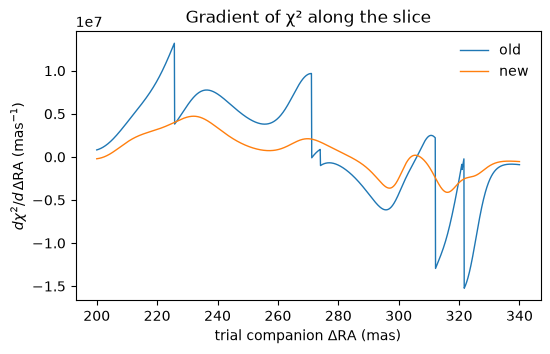

In [4]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(dra, jax.vmap(jax.grad(chi2_old))(dra), label="old", lw=1)
ax.plot(dra, jax.vmap(jax.grad(chi2_new))(dra), label="new", lw=1)
ax.set(
    xlabel=r"trial companion $\Delta$RA (mas)",
    ylabel=r"$d\chi^2 / d\,\Delta$RA (mas$^{-1}$)",
    title="Gradient of χ² along the slice",
)
ax.legend(frameon=False)
plt.show()

## A side benefit in float32

The old wrap computes mod(Δ + π, 2π) − π. Adding π to a small residual in float32 throws away its low-order digits, because the spacing of float32 numbers near π is about 2.4e-7 rad. The chord never adds π, so it keeps full precision. Here a residual of 6e-4 rad is compared with its exact value in both forms.

In [5]:
exact = 6.0e-4
residual = jnp.float32(exact)
old = jnp.mod(residual + jnp.pi, 2 * jnp.pi) - jnp.pi
new = 2 * jnp.sin(residual / 2)
print(
    f"relative error of the wrapped residual: {abs(float(old) - exact) / exact:.1e}"
)
print(
    f"relative error of the chord:            {abs(float(new) - 2 * onp.sin(exact / 2)) / exact:.1e}"
)

relative error of the wrapped residual: 1.7e-04
relative error of the chord:            6.2e-08


## Summary

The new closure-phase term is a von Mises likelihood written as a residual. It equals the old Gaussian term for well-fitting models (the Stage 0 regression changes were at most 0.005 in log-likelihood near the peak), but it removes the kinks in χ² and the jumps in its gradient wherever phases wrap, and it avoids a loss of float32 precision in small residuals. Because `whitened_residuals` is also a residual vector, the same term works for least-squares fitting (Levenberg–Marquardt) in Stage 3.